<a href="https://colab.research.google.com/github/lenovo-2026/COINSI/blob/main/Algoritmos_gen%C3%A9ticos_ejercicios.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PyGAD
Es una librería de Python especializada en algoritmos genéticos. Su propósito es facilitar la implementación de procesos evolutivos para resolver problemas de optimización, tanto continuos como combinatorios, sin que el programador tenga que construir desde cero toda la lógica de selección, cruce y mutación.

 **Ejercicio 1:** Optimización de una función matemática
Función objetivo:
f(x)=x^2-4x+6
Queremos encontrar el valor de x que maximiza esta función.

In [ ]:
# Paso 1: Instalar pygad e importar librerías necesarias
!pip install pygad

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.8/91.8 kB 5.6 MB/s eta 0:00:00


In [ ]:
import pygad
import numpy as np

In [ ]:
# Paso 2: Definir la función de aptitud (fitness)
# Esta función recibe una solución candidata y devuelve su "calidad".
def fitness_func(ga_instance, solution, solution_idx):
    x = solution[0]  # Tomamos el único gen (variable x)
    return x**2 - 4*x + 6  # Evaluamos la función objetivo

In [ ]:
# Paso 3: Configurar el algoritmo genético
ga_instance = pygad.GA(
    num_generations=50,      # Número de generaciones (iteraciones del algoritmo)
    num_parents_mating=2,    # Número de padres seleccionados para cruzarse en cada generación
    fitness_func=fitness_func, # Función de aptitud definida arriba
    sol_per_pop=10,          # Número de soluciones (individuos) en cada población
    num_genes=1,             # Número de genes por individuo (solo una variable: x)
    gene_space={'low': -10, 'high': 10} # Rango permitido para el gen (x entre -10 y 10)
)

/usr/local/lib/python3.12/dist-packages/pygad/utils/validation.py:670: UserWarning: The percentage of genes to mutate (mutation_percent_genes=10) resulted in selecting (0) genes. The number of genes to mutate is set to 1 (mutation_num_genes=1).
If you do not want to mutate any gene, please set mutation_type=None.
  warnings.warn(


In [ ]:
# Paso 4: Ejecutar el algoritmo genético
ga_instance.run()

In [ ]:
# Paso 5: Obtener la mejor solución encontrada
solution, solution_fitness, _ = ga_instance.best_solution()
print(f"Mejor valor de x: {solution[0]}")
print(f"Valor máximo de la función: {solution_fitness}")

Mejor valor de x: -9.971376521654358
Valor máximo de la función: 145.3138558232172


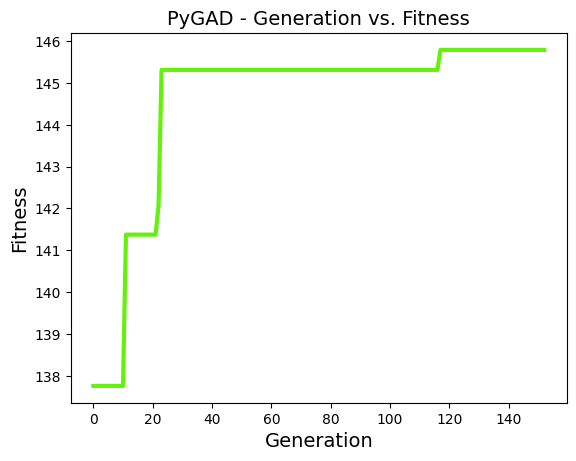

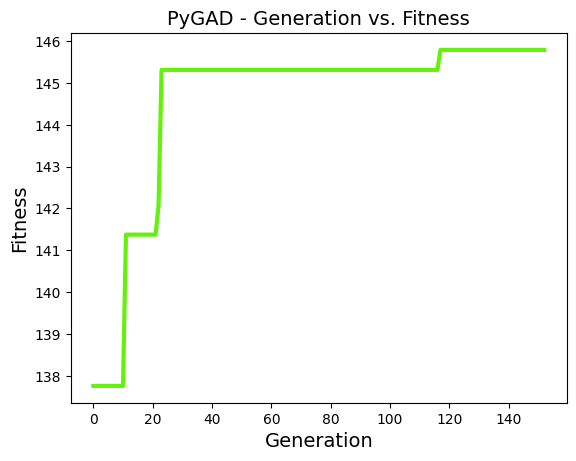

In [ ]:
# Paso 6: Gráficas
ga_instance.run()

# Graficar la evolución del fitness
ga_instance.plot_fitness()

**Ejercicio 2:** Problema de la mochila (Knapsack Problem)
Datos del problema:
- Pesos = [3, 4, 7, 8, 9]
- Valores = [3, 5, 8, 9, 10]
- Capacidad máxima = 15


In [ ]:
# Paso 1: Definir datos del problema
weights = [3, 4, 7, 8, 9]   # Pesos de los objetos
values = [3, 5, 8, 9, 10]   # Valores de los objetos
capacity = 15               # Capacidad máxima de la mochila


In [ ]:

# Paso 2: Definir la función de aptitud
def fitness_func(ga_instance,solution, solution_idx):
    # Cada gen de la solución es 0 o 1 (no incluir / incluir el objeto)
    total_weight = np.sum(solution * weights)  # Peso total de la selección
    total_value = np.sum(solution * values)    # Valor total de la selección

    # Penalización si excede la capacidad
    if total_weight > capacity:
        return 0
    return total_value


In [ ]:
# Paso 3: Configurar el algoritmo genético
ga_instance = pygad.GA(
    num_generations=100,     # Número de generaciones
    num_parents_mating=5,    # Número de padres seleccionados para cruzarse
    fitness_func=fitness_func, # Función de aptitud definida arriba
    sol_per_pop=20,          # Número de soluciones en cada población
    num_genes=len(weights),  # Número de genes = número de objetos
    gene_space=[0, 1]        # Cada gen puede ser 0 (no incluir) o 1 (incluir)
)


In [ ]:
# Paso 4: Ejecutar el algoritmo genético
ga_instance.run()


In [ ]:
# Paso 5: Obtener la mejor solución encontrada
solution, solution_fitness, _ = ga_instance.best_solution()
print(f"Selección óptima: {solution}")
print(f"Valor máximo: {solution_fitness}")

Selección óptima: [1. 1. 0. 1. 0.]
Valor máximo: 17.0


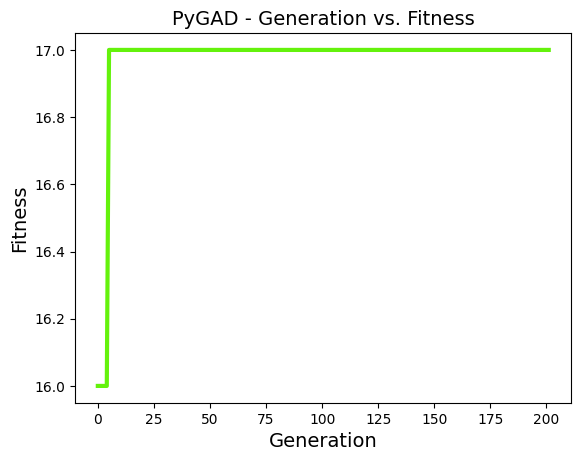

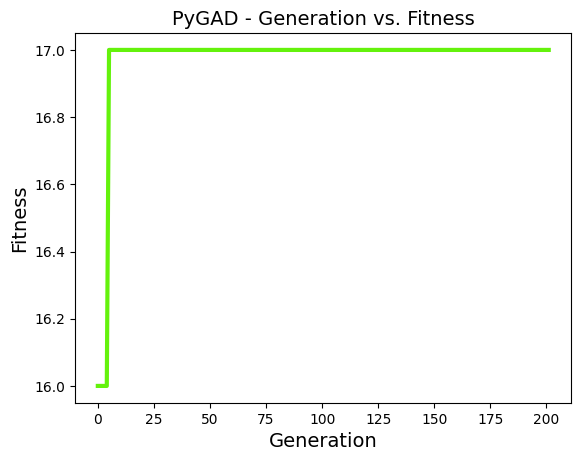

In [ ]:
# Paso 6: Gráficas
ga_instance.run()

# Graficar el progreso
ga_instance.plot_fitness()

**Ejercicio 3:** Ajuste de parámetros para minimizar una función multivariable.

**Función objetivo:**
f(x,y)=(x-3)^2+(y+2)^2
El objetivo es encontrar los valores de x y y que minimizan la función (es decir, acercarse al punto (3,-2)).


In [ ]:
# Paso 1: Definir la función de aptitud (fitness)
# En este caso queremos minimizar, pero PyGAD maximiza por defecto.
# Por ello devolvemos el inverso (negativo) del valor de la función.
def fitness_func(ga_instance, solution, solution_idx):
    x, y = solution  # Dos genes: x y y
    result = (x - 3)**2 + (y + 2)**2
    return -result  # Negativo para que el GA busque minimizar



In [ ]:
# Paso 2: Configurar el algoritmo genético
ga_instance = pygad.GA(
    num_generations=80,       # Número de generaciones (iteraciones)
    num_parents_mating=4,     # Padres seleccionados para cruzarse
    fitness_func=fitness_func,# Función de aptitud definida arriba
    sol_per_pop=15,           # Número de individuos en cada población
    num_genes=2,              # Dos genes: x y y
    gene_space={'low': -10, 'high': 10}, # Rango permitido para cada gen
    mutation_probability=0.1, # Probabilidad de mutación (10%)
    crossover_type="single_point", # Tipo de cruce: un punto
    mutation_type="random"    # Tipo de mutación: valores aleatorios
)



In [ ]:
# Paso 3: Ejecutar el algoritmo genético
ga_instance.run()


In [ ]:

# Paso 4: Obtener la mejor solución encontrada
solution, solution_fitness, _ = ga_instance.best_solution()
print(f"Mejor solución encontrada: x={solution[0]}, y={solution[1]}")
print(f"Valor mínimo aproximado de la función: {-solution_fitness}")

Mejor solución encontrada: x=2.7769010058418093, y=-2.286594812892142
Valor mínimo aproximado de la función: 0.1319097479710783


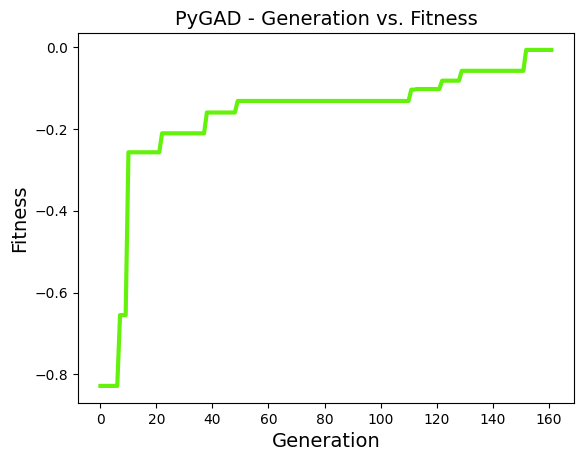

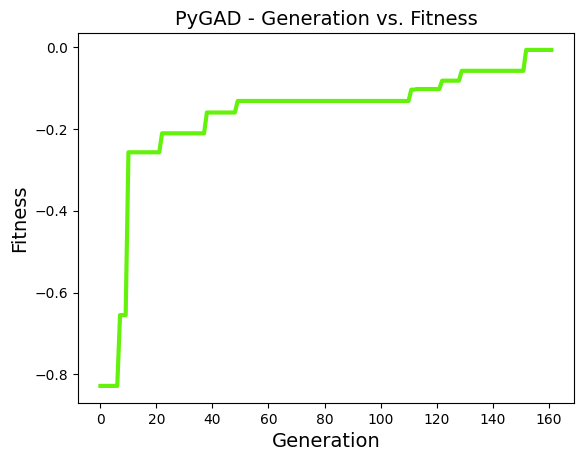

In [ ]:
# Paso 5: Gráficas
ga_instance.run()

# Graficar el progreso
ga_instance.plot_fitness()

# Implementación sin la librería PyGAD

Observa los resultados obtenidos y describe las diferencias encontradas al usar la librería PyGAD. Explica.

Haz lo mismo para los ejercicios 2 y 3.

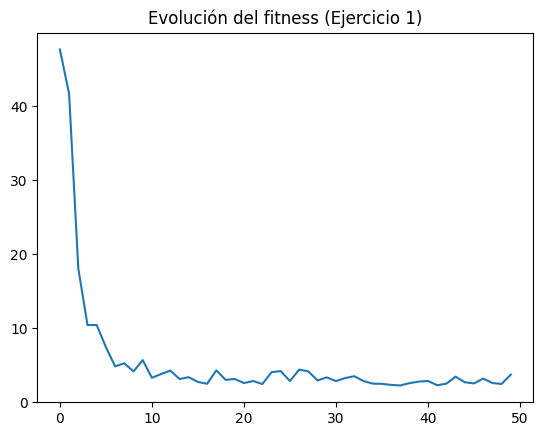

In [ ]:
# Ejercicio 1:
import numpy as np              # Librería para cálculos numéricos
import random                   # Para generar números aleatorios
import matplotlib.pyplot as plt # Para graficar resultados

# Función de aptitud: mide la calidad de una solución
def fitness(individual):
    x = individual[0]           # Tomamos el único gen (variable x)
    return x**2 - 4*x + 6       # Evaluamos la función objetivo

# Crear población inicial
def create_population(pop_size):
    # Cada individuo es un número aleatorio entre -10 y 10
    return [np.array([random.uniform(-10, 10)]) for _ in range(pop_size)]

# Selección: elegimos dos padres al azar
def select_parents(population):
    return random.choice(population), random.choice(population)

# Cruce: el hijo es el promedio de los genes de los padres
def crossover(p1, p2):
    return np.array([(p1[0] + p2[0]) / 2])

# Mutación: con probabilidad 0.1 se altera el valor de x
def mutate(individual, rate=0.1):
    if random.random() < rate:
        individual[0] += random.uniform(-1, 1)
    return individual

# Evolución del algoritmo genético
pop = create_population(20)     # Población inicial de 20 individuos
best_scores = []                # Lista para guardar el mejor fitness
for gen in range(50):           # 50 generaciones
    new_pop = []
    for _ in range(len(pop)):
        p1, p2 = select_parents(pop)   # Selección
        child = crossover(p1, p2)      # Cruce
        child = mutate(child)          # Mutación
        new_pop.append(child)
    pop = new_pop
    best = max(pop, key=fitness)       # Mejor individuo de la generación
    best_scores.append(fitness(best))  # Guardamos su fitness

# Graficar evolución del fitness
plt.plot(best_scores)
plt.title("Evolución del fitness (Ejercicio 1)")
plt.show()
